### 데이터를 가지고 똑똑한 [예측 가이드북]을 만드는 작업

### 1. "모델"이 뭐야? (예측 가이드북)  

상황: 어떤 사람이 병원에 왔는데, 이 사람이 '체지방'이 높을지 낮을지 미리 맞추고 싶다고 해볼게요.

모델: 그동안 쌓인 데이터(나이, 몸무게, 허벅지 둘레 등)를 AI에게 보여주면, AI가 "나이가 42세 이상이고 허벅지가 두꺼우면 체지방이 높더라!" 같은 규칙을 찾아내겠죠?

결론: 그 찾아낸 규칙들의 집합이 바로 '모델'입니다. 새로운 사람이 왔을 때 이 가이드북(모델)에 넣으면 결과값을 탁 뱉어주는 거예요.

### 2. 왜 자꾸 나무(Graphviz)를 그려?  

우리가 쓰는 방법이 의사결정 나무(Decision Tree)라서 그래요.

AI가 내부적으로 "나이 > 42세?" 같은 질문을 던지며 데이터를 가르는데, 이게 마치 나뭇가지가 뻗어 나가는 모양이랑 똑같거든요.

그리는 이유: AI가 어떤 기준으로 그런 결론을 내렸는지 우리 눈으로 직접 확인하려고 그리는 거예요. "아, 나이가 제일 중요했구나!"라고 사람이 이해하기 위해서요.

### 3. 숫자를 왜 자꾸 바꿔? (Leaf, Split 등)  

나무가 너무 복잡하면: 연습문제(Train)는 다 외우지만, 처음 보는 실전 문제(Test)는 못 푸는 바보가 됩니다. (너무 깐깐한 선생님)

나무가 너무 단순하면: 아예 공부를 안 한 거라 아무것도 못 맞춥니다. (너무 대충 가르치는 선생님)

결론: 가장 적당한 수준으로 나무를 키우기 위해 "최소 몇 명일 때 가지를 칠까?" 같은 숫자를 요리조리 바꿔보며 최고의 성능을 내는 황금 비율을 찾는 거예요.

### 4. 전체 과정 요약  

데이터 준비: 과거의 기록들을 가져옵니다.

나무 키우기 (학습): AI에게 규칙을 찾으라고 시킵니다.

가지치기 (튜닝): 나무가 너무 복잡하거나 단순하지 않게 숫자를 조절합니다.

최종 확인: 가장 점수가 잘 나오는 나무를 완성하고, "아, 이런 규칙으로 예측하는구나!" 하고 그래프를 보며 흐뭇해합니다.

### 💡 한마디로 지금 당신은...
**"나이와 신체 데이터를 넣으면 결과값을 찰떡같이 맞춰주는 [예측 AI 가이드북]을 가장 예쁘고 정확하게 다듬고 있는 중"**입니다!

지금 보고 계신 그 나무 그림이 바로 그 가이드북의 설계도인 셈이죠.

#### 과대적합이 커지는 이유
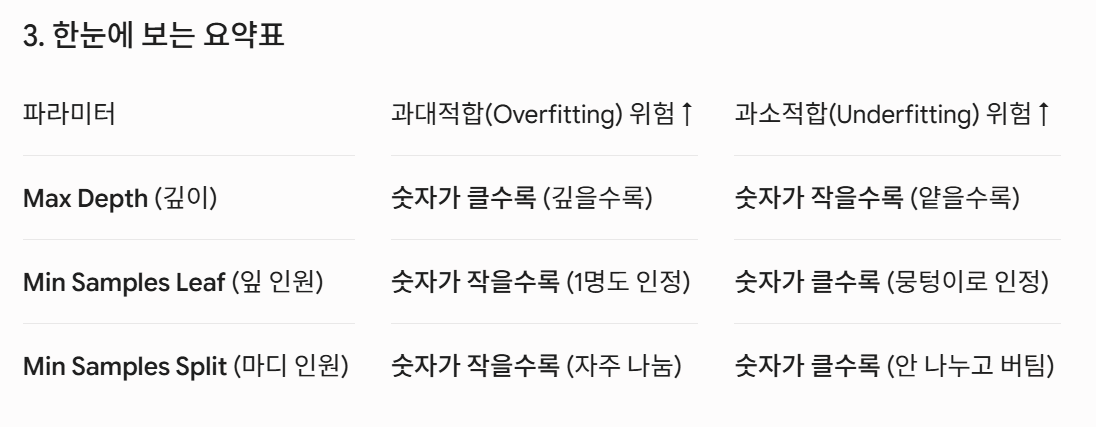



In [2]:
# 98 Page
# 데이터 구성:Series, DataFrame
import pandas as pd
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib
# export_graphviz: 나무 구조 생성 및 저장 
from sklearn.tree import export_graphviz
# graphviz : 나무 구조 시각화  (.dot 확장자 파일 불러오기 등)
import graphviz
# 데이터 분할:train, test
from sklearn.model_selection import train_test_split
# 예측/회귀 Decision Tree
from sklearn.tree import DecisionTreeRegressor
# 최적 모델, 파라미터 탐색
from sklearn.model_selection import GridSearchCV

In [3]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

In [1]:
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "Malgun Gothic")
# 음수 표시
matplotlib.rc('axes', unicode_minus=False)

In [5]:
# 100 Page
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\체질검사.csv", encoding = "euc-kr")
df_raw.head()

,FAT,AGE,WEIGHT,HEIGHT,NECK,CHEST,ABDOMEN,HIP,THIGH,KNEE,ANKLE,BICEPS,FOREARM,WRIST,GENDER
0,35.2,46,363.15 lb,72.25 inch,51.2,136.2,148.1,147.7,87.3,49.1,29.6,45.0,29.0,21.4,남성
1,11.8,27,168 lb,71.25 inch,38.1,93.0,79.1,94.5,57.3,36.2,24.5,29.0,30.0,18.8,남성
2,22.2,69,177.75 lb,68.5 inch,38.7,102.0,95.0,98.3,55.0,38.3,21.8,30.8,25.7,18.8,남성
3,10.6,57,147.75 lb,65.75 inch,35.2,99.6,86.4,90.1,53.0,35.0,21.3,31.7,27.3,16.9,여성
4,47.5,51,219 lb,64 inch,41.2,119.8,122.1,112.8,62.5,36.9,23.6,34.7,29.1,18.4,여성


## 단위

In [6]:
# 단위와 같이 표현되어 있는 수치형 변수 처리
df_raw[['WEIGHT', 'WEIGHT_UNIT']] = df_raw['WEIGHT'].str.split(expand = True)
df_raw[['HEIGHT', 'HEIGHT_UNIT']] = df_raw['HEIGHT'].str.split(expand = True)
df_raw['WEIGHT'] = df_raw['WEIGHT'].astype('float64')
df_raw['HEIGHT'] = df_raw['HEIGHT'].astype('float64')

## 더미

In [ ]:
# 단위를 나타내는 항목 제외
df_raw = df_raw.drop(['WEIGHT_UNIT', 'HEIGHT_UNIT'], axis = 1)

# 
# 범주형 변수의 Dummy 변수화
df_raw_dummy = pd.get_dummies(df_raw)
df_raw_dummy.head()

,FAT,AGE,WEIGHT,HEIGHT,NECK,CHEST,ABDOMEN,HIP,THIGH,KNEE,ANKLE,BICEPS,FOREARM,WRIST,GENDER_남성,GENDER_여성
0,35.2,46,363.15,72.25,51.2,136.2,148.1,147.7,87.3,49.1,29.6,45.0,29.0,21.4,1,0
1,11.8,27,168.00,71.25,38.1,93.0,79.1,94.5,57.3,36.2,24.5,29.0,30.0,18.8,1,0
2,22.2,69,177.75,68.50,38.7,102.0,95.0,98.3,55.0,38.3,21.8,30.8,25.7,18.8,1,0
3,10.6,57,147.75,65.75,35.2,99.6,86.4,90.1,53.0,35.0,21.3,31.7,27.3,16.9,0,1
4,47.5,51,219.00,64.00,41.2,119.8,122.1,112.8,62.5,36.9,23.6,34.7,29.1,18.4,0,1



GENDER_남성	GENDER_여성 컬럼이 생김

In [8]:
# 101 Page
# 목표변수, 설명변수 데이터 지정
df_raw_y = df_raw_dummy["FAT"]
df_raw_x = df_raw_dummy.drop("FAT", axis = 1, inplace = False)

## 데이터 분할 7;3

In [9]:
# train_test_split(X: 설명변수 데이터, Y: 목표변수 데이터, test_size = test 데이터 비율, random_state: random seed)
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, df_raw_y
                                                                , test_size = 0.3, random_state = 1234) 
print("train data X size : {}".format(df_train_x.shape))
print("train data Y size : {}".format(df_train_y.shape))
print("test data X size : {}".format(df_test_x.shape))
print("test data Y size : {}".format(df_test_y.shape))

train data X size : (176, 15)
train data Y size : (176,)
test data X size : (76, 15)
test data Y size : (76,)


In [12]:
# 102 Page
# 모델 생성
tree_uncustomized = DecisionTreeRegressor(random_state=1234)
tree_uncustomized.fit(df_train_x, df_train_y)
# Train 데이터 설명력
print("Score on training set: {:.3f}".format(tree_uncustomized.score(df_train_x, df_train_y)))
# test 데이터 설명력
print("Score on test set: {:.3f}".format(tree_uncustomized.score(df_test_x, df_test_y)))

Score on training set: 1.000
Score on test set: 0.377


100퍼네 매우 성능이 좋네? 근데 테스트 셋으로 하니까 37뿐이네 아 간극이 크다 = 과대 적합이다!

In [11]:
tree_uncustomized.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 1234,
 'splitter': 'best'}

## STEP 2 이제 모델을 튜닝합니다 

leaf 변경해가면서 어떤 모델이 좋을까 생각해보자

In [ ]:
# 103 Page
# train 및 test 설명력 결과 저장
train_score = []; test_score = [ ]
# min_samples_leaf: 잎사귀 최소 자료 수
para_leaf = [n_leaf for n_leaf in range(1, 20)] #1, 2, 3, ... 19개 까지 생성하고 저장시켜서 리스트로 만들어주는 명령어

for v_min_samples_leaf in para_leaf:
    tree = DecisionTreeRegressor(random_state=1234
                                 , min_samples_leaf=v_min_samples_leaf)
    tree.fit(df_train_x, df_train_y)
    train_score.append(tree.score(df_train_x, df_train_y))
    test_score.append(tree.score(df_test_x, df_test_y))

# 결과 저장
df_score_leaf = pd.DataFrame()
df_score_leaf["MinSamplesLeaf"] = para_leaf
df_score_leaf["TrainScore"] = train_score
df_score_leaf["TestScore"] = test_score

In [15]:
# 104 Page
# 모델 설명력 확인
df_score_leaf.round(3)

,MinSamplesLeaf,TrainScore,TestScore
0,1,1.000,0.377
1,2,0.970,0.363
2,3,0.928,0.456
3,4,0.904,0.454
4,5,0.869,0.449
5,6,0.853,0.445
6,7,0.843,0.465
7,8,0.830,0.536
8,9,0.802,0.477
9,10,0.793,0.505


위 애를 그래프로 그려보자

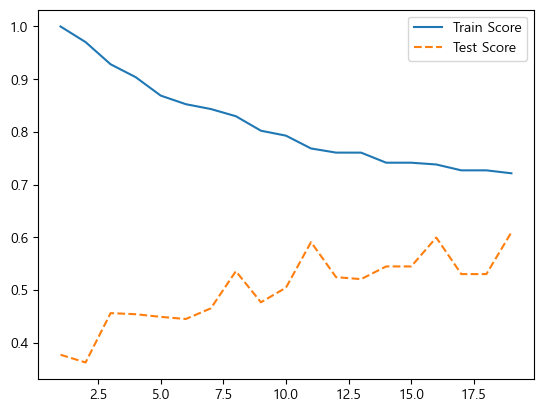

In [16]:
# 모델 설명력 그래프 확인
plt.plot(para_leaf, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_leaf, test_score, linestyle = "--", label = "Test Score")
plt.legend()

숫자가 늘어날수록 과대 적합이 적어진다  
8과 16을 봅시당  
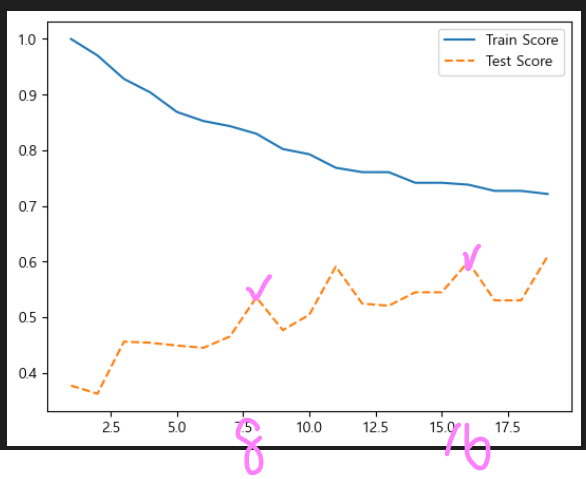

In [ ]:
# 우분투!!!!!!!
# 변수명 저장
v_feature_name = df_train_x.columns
# 노드의 최소 자료수 = 8 모델 
tree_graph = DecisionTreeRegressor(random_state=1234,  min_samples_leaf=8)
tree_graph.fit(df_train_x, df_train_y)
export_graphviz(tree_graph, out_file="tree_leaf.dot",
                feature_names = v_feature_name, impurity = True, filled = True)
with open("tree_leaf.dot") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

PDF에 넣어봅시다

In [22]:
src = graphviz.Source(dot_graph)
src.view()

'Source.gv.pdf'

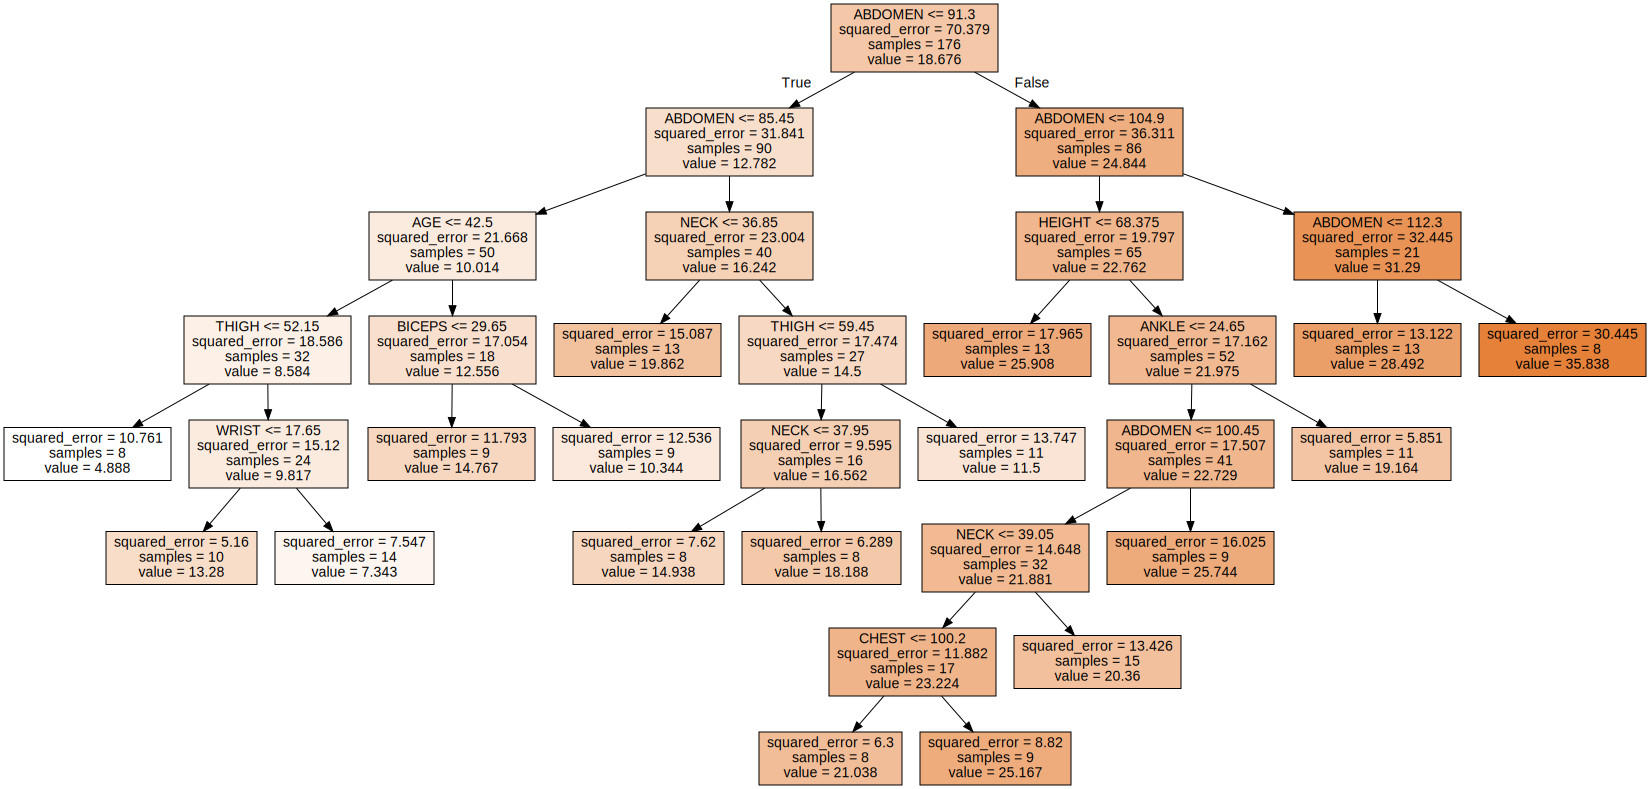

In [ ]:
# 윈도우 !!!!!!!!!!!!!!!!!!!!!!!!!!!
import os
import graphviz
from sklearn.tree import export_graphviz
from sklearn.tree import DecisionTreeRegressor

# 1. 윈도우 환경 변수 경로 직접 추가 (반드시 추가하세요!)
# 설치 위치에 따라 'Program Files' 또는 'Program Files (x86)' 중 하나를 선택하세요.
os.environ["PATH"] += os.pathsep + 'C:/Program Files (x86)/Graphviz/bin'
# 만약 위 경로가 아니라면 아래 주석을 해제하고 사용하세요.
# os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin'

# 105 Page 실습 코드
v_feature_name = df_train_x.columns

tree_graph = DecisionTreeRegressor(random_state=1234, min_samples_leaf=8)
tree_graph.fit(df_train_x, df_train_y)

export_graphviz(tree_graph, out_file="tree_leaf.dot",
                feature_names = v_feature_name, impurity = True, filled = True)

with open("tree_leaf.dot") as f:
    dot_graph = f.read()

# 이제 에러 없이 그래프가 출력될 것입니다.
display(graphviz.Source(dot_graph))

In [23]:
src = graphviz.Source(dot_graph)
src.view()

'Source.gv.pdf'

가장 핵심적인 결론을 세 줄로 요약하면 이렇습니다.

제일 중요한 기준: 이 데이터에서 결과값을 결정하는 가장 큰 요인은 나이(AGE, 42.5세 기준)입니다.

나이가 적다면(왼쪽): 그다음으로 허벅지(THIGH) 치수가 중요하며, 허벅지가 가늘수록 결과값이 낮아집니다.

나이가 많다면(오른쪽): 그다음으로 이두근(BICEPS) 치수가 중요하며, 팔 근육 수치에 따라 결과값이 크게 달라집니다.

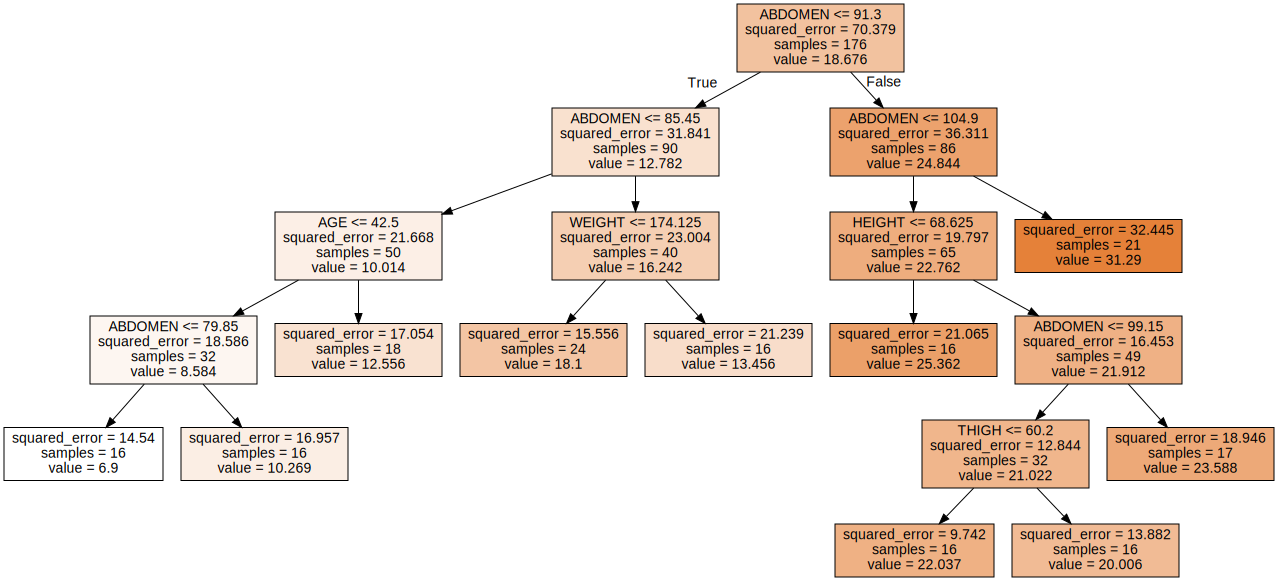

In [20]:
# 노드의 최소 자료 수=16 모델
tree_graph = DecisionTreeRegressor(random_state=1234,  min_samples_leaf=16 )
tree_graph.fit(df_train_x, df_train_y)
export_graphviz(tree_graph, out_file="tree_leaf.dot",
                feature_names = v_feature_name, impurity = True, filled = True)
with open("tree_leaf.dot") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

In [24]:
src = graphviz.Source(dot_graph)
src.view()

'Source.gv.pdf'

In [ ]:
# 107 Page
# train 및 test 설명력 결과 저장
train_score = []; test_score = []

# min_samples_split: 분리 노드의 최소 자료 수 
# "노드를 나눌 때 최소한 이 정도 데이터는 있어야 해"라는 
# 기준값을 4부터 38까지 2씩 커지게 만들라는 뜻입니다. 
para_split
para_split = [n_split * 2 for n_split in range(2, 20)] # 1은 트리니까?


for v_min_samples_split in para_split:
    tree = DecisionTreeRegressor(random_state=1234, min_samples_leaf=8      ## leaf를 8개로!
                                 , min_samples_split=v_min_samples_split )
    tree.fit(df_train_x, df_train_y)
    train_score.append(tree.score(df_train_x, df_train_y))
    test_score.append(tree.score(df_test_x, df_test_y))

# 결과 저장
df_score_split = pd.DataFrame()
df_score_split["MinSamplesSplit"] = para_split
df_score_split["TrainScore"] = train_score
df_score_split["TestScore"] = test_score

In [26]:
# 108 Page
df_score_split.round(3)

,MinSamplesSplit,TrainScore,TestScore
0,4,0.830,0.536
1,6,0.830,0.536
2,8,0.830,0.536
3,10,0.830,0.536
4,12,0.830,0.536
5,14,0.830,0.536
6,16,0.830,0.536
7,18,0.821,0.557
8,20,0.813,0.581
9,22,0.792,0.567


표로 한 번 보자

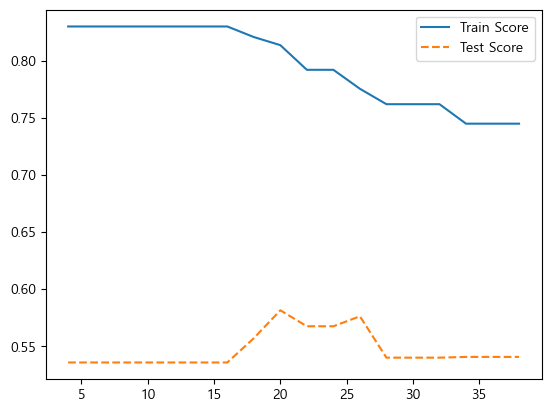

In [28]:
# 모델 설명력 그래프 확인

plt.plot(para_split, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_split, test_score, linestyle = "--", label = "Test Score")
plt.legend()

20하고 26인 것 같은뎅? 주변보다 커
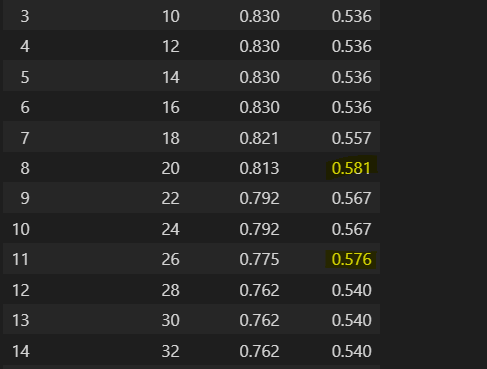

### 이걸 계속 반복하는거임

먼저 20으로 해볼게

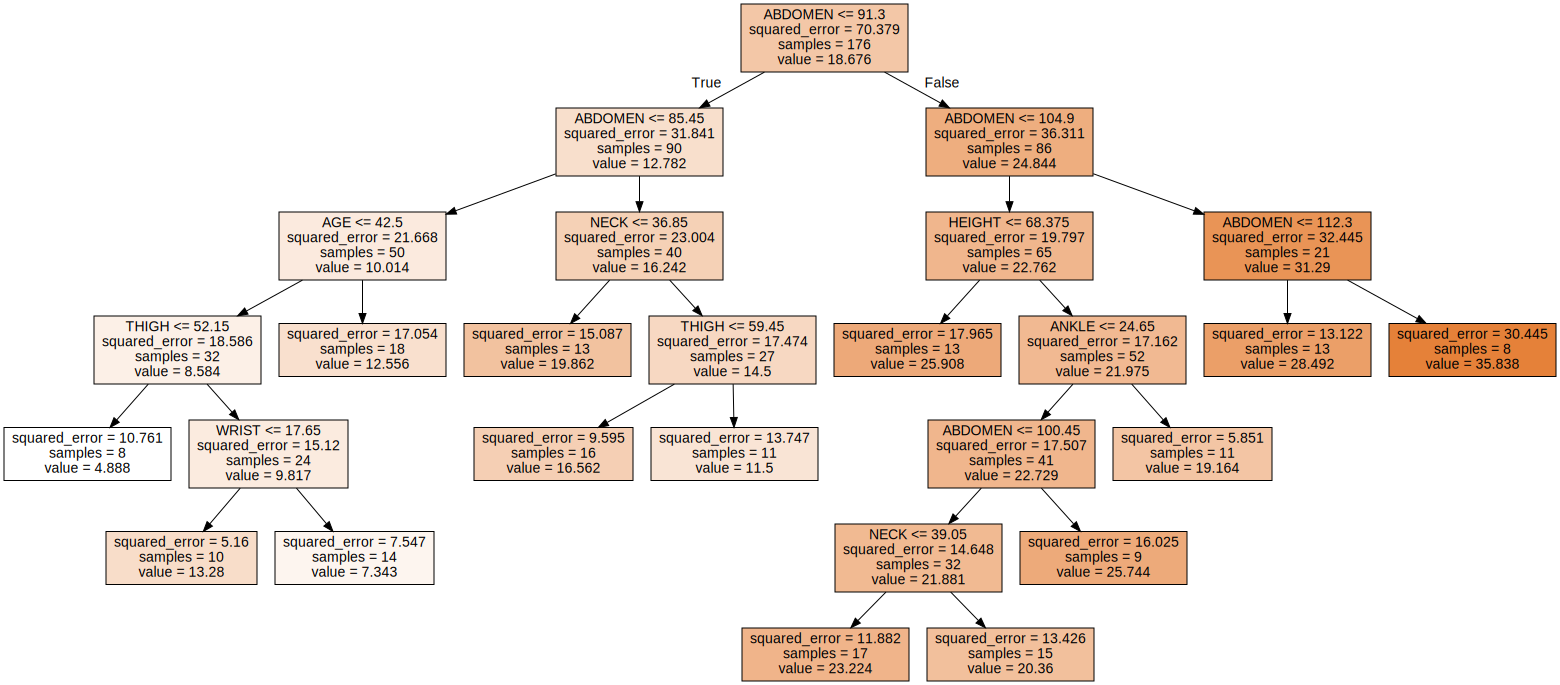

In [ ]:
# 109 Page
# # 분리 노드의 최소 자료 수= 20 모델

# min_samples_leaf=8: 잎사귀에 최소 8명은 있게 해라.
# min_samples_split=20: 마디를 나눌 땐 최소 20명은 있어야 한다.
tree_graph = DecisionTreeRegressor(random_state=1234, min_samples_leaf=8, min_samples_split=20 )
tree_graph.fit(df_train_x, df_train_y)
export_graphviz(tree_graph, out_file="tree_split.dot",
                feature_names = v_feature_name, impurity = True, filled = True)
with open("tree_split.dot") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

In [30]:
src = graphviz.Source(dot_graph)
src.view()

'Source.gv.pdf'

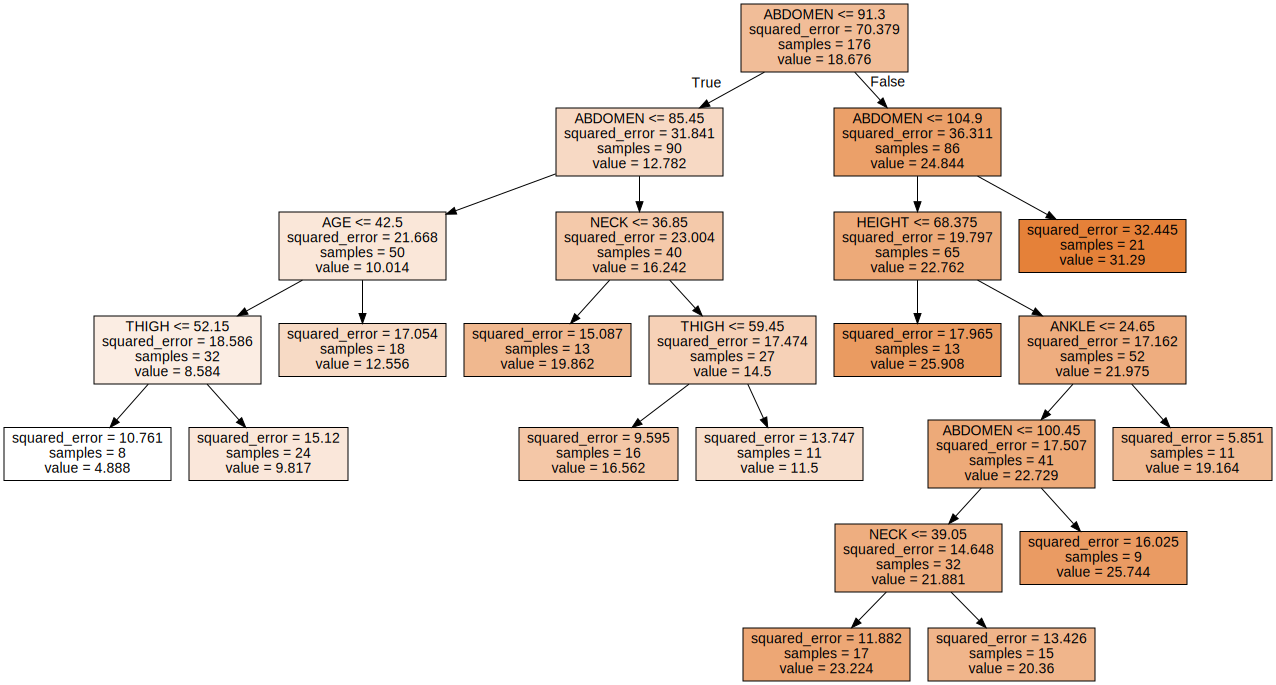

In [31]:
# 분리 노드의 최소 자료 수=26 모델
tree_graph = DecisionTreeRegressor(random_state=1234, min_samples_leaf=8, min_samples_split=26 )
tree_graph.fit(df_train_x, df_train_y)
export_graphviz(tree_graph, out_file="tree_split.dot",
                feature_names = v_feature_name, impurity = True, filled = True)
with open("tree_split.dot") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

#### 깊이를 설정하는 이유 : AI의 생각의 깊이를 제한해서 과대적합이 되는 걸 막기 위해서

In [32]:
# 111 Page
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# max_depth: 최대 깊이 변경
para_depth = [depth for depth in range(1, 11)]

for v_max_depth in para_depth:
    tree = DecisionTreeRegressor(random_state=1234, min_samples_leaf=8, min_samples_split=20
                                  , max_depth = v_max_depth)
    tree.fit(df_train_x, df_train_y)
    train_score.append(tree.score(df_train_x, df_train_y))
    test_score.append(tree.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_score_depth = pd.DataFrame()
df_score_depth["Depth"] = para_depth
df_score_depth["TrainScore"] = train_score
df_score_depth["TestScore"] = test_score

In [45]:
# 112 Page # 설명 읽어보기
#  모델 설명력 확인
df_score_depth.round(3)

,Depth,TrainScore,TestScore
0,1,0.517,0.333
1,2,0.679,0.569
2,3,0.749,0.538
3,4,0.783,0.570
4,5,0.808,0.581
5,6,0.813,0.581
6,7,0.813,0.581
7,8,0.813,0.581
8,9,0.813,0.581
9,10,0.813,0.581


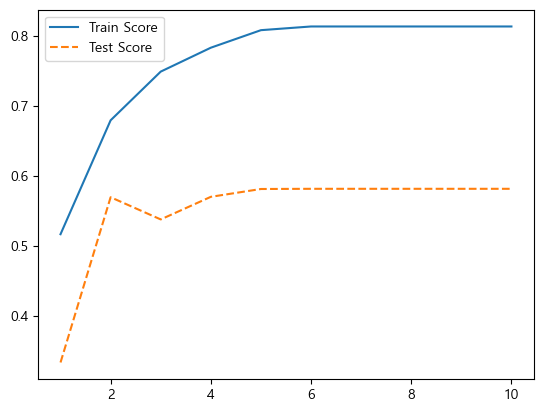

In [35]:
# 모델 설명력 그래프 확인
plt.plot(para_depth, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_depth, test_score, linestyle = "--", label = "Test Score")
plt.legend()

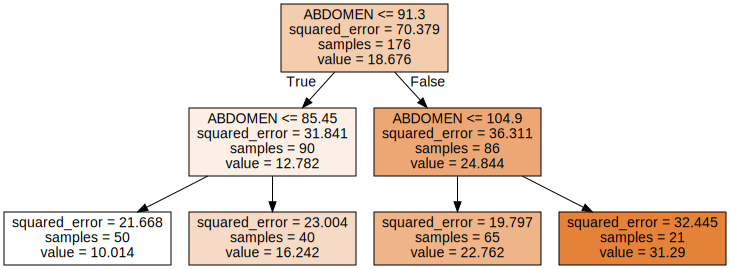

In [36]:
# 113 Page
# 최대 깊이 = 2 모델
tree_graph = DecisionTreeRegressor(random_state=1234, min_samples_leaf=8, min_samples_split=20, max_depth = 2 )
tree_graph.fit(df_train_x, df_train_y)

export_graphviz(tree_graph, out_file="tree_depth.dot",
                feature_names = v_feature_name, impurity = True, filled = True)
with open("tree_depth.dot") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

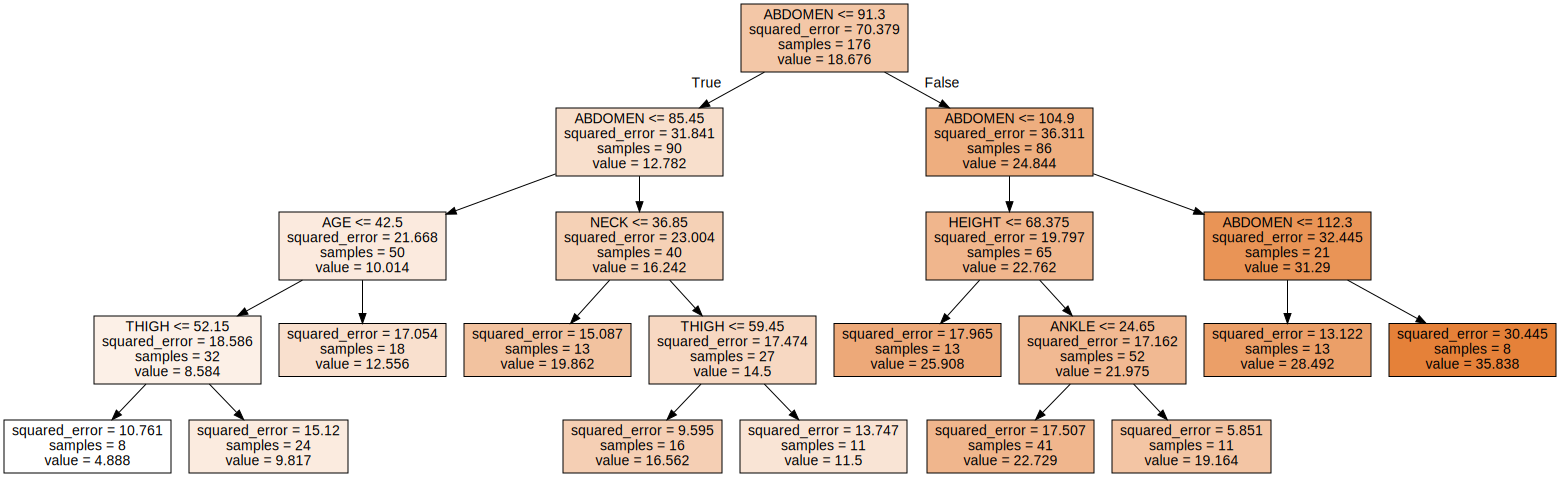

In [37]:
# 최대 깊이 = 4 모델
tree_graph = DecisionTreeRegressor(random_state=1234, min_samples_leaf=8, min_samples_split=20, max_depth = 4 )
tree_graph.fit(df_train_x, df_train_y)
export_graphviz(tree_graph, out_file="tree_depth.dot",
                feature_names = v_feature_name, impurity = True, filled = True)
with open("tree_depth.dot") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

In [41]:
src = graphviz.Source(dot_graph)
src.view()

'Source.gv.pdf'


# 최종 회귀 모델

In [ ]:
# 115 Page
# 최종 회귀 모델
v_feature_name = df_train_x.columns
tree_final = DecisionTreeRegressor(min_samples_leaf = 8, min_samples_split = 20, max_depth = 4, random_state=1234, )
tree_final.fit(df_train_x, df_train_y)
tree_final.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 4,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 8,
 'min_samples_split': 20,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 1234,
 'splitter': 'best'}

# 데이터 설명력

In [44]:

# Train 데이터 설명력
print("Score on training set: {:.3f}".format(tree_final.score(df_train_x, df_train_y)))
# test 데이터 설명력
print("Score on test set: {:.3f}".format(tree_final.score(df_test_x, df_test_y)))

Score on training set: 0.783
Score on test set: 0.570


In [42]:
# 평가용 데이터에 대한 실제값과 예측값 확인(10개 확인)
test_pred = tree_final.predict(df_test_x)
print('test data의 실제값 : \n', df_test_y[:10])
print('test data의 예측값 : \n', test_pred[:10])

test data의 실제값 : 
 208     8.0
94      9.6
31     34.3
248    23.6
216    31.4
6      23.3
91      5.2
73     12.5
129    13.9
5      24.2
Name: FAT, dtype: float64
test data의 예측값 : 
 [12.55555556 22.72926829 35.8375     16.5625     25.90769231 16.5625
 12.55555556  4.8875     16.5625     22.72926829]


# 파이널 트리그림

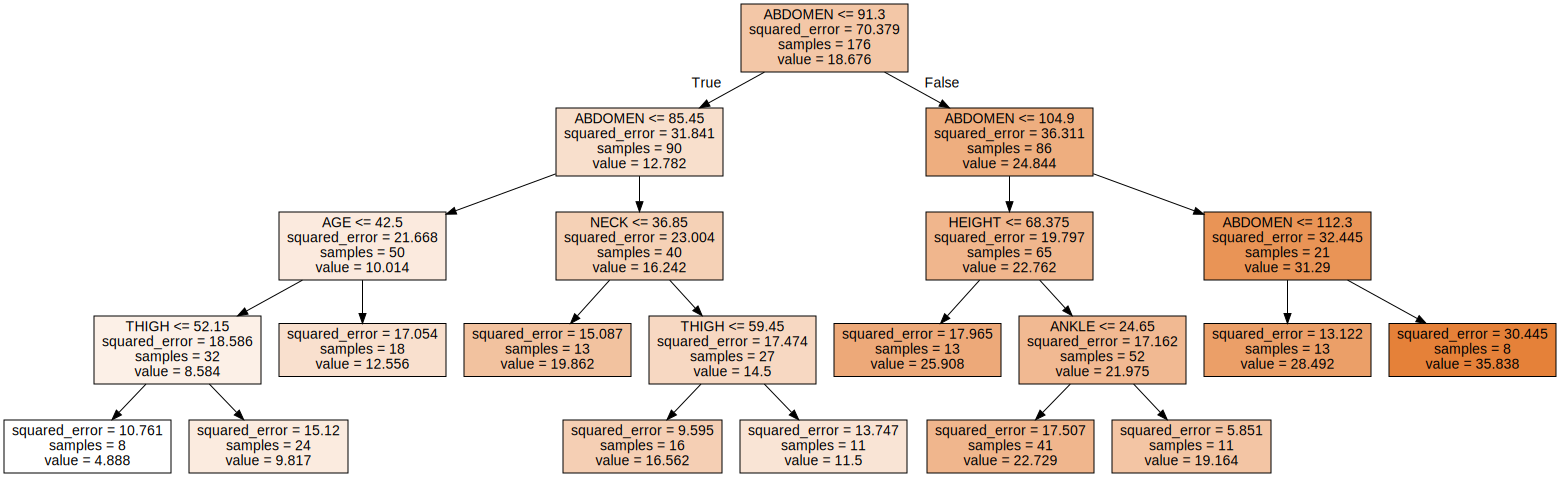

<Figure size 700x700 with 0 Axes>

In [46]:
export_graphviz(tree_final, out_file="tree_final.dot",
                feature_names = v_feature_name, impurity = True, filled = True)

with open("tree_final.dot") as f:
    dot_graph = f.read()
plt.figure(figsize = (7, 7))
display(graphviz.Source(dot_graph))

In [47]:
# 117 Page
# tree.feature_importances_로 설명변수 중요도 확인 및 테이블로 저장
df_importance = pd.DataFrame()
df_importance["Feature"] = v_feature_name
df_importance["Importance"] = tree_final.feature_importances_

# df_feature_importance의 테이블을 중요도별로 정렬
df_importance.sort_values("Importance", ascending=False, inplace = True)
df_importance.round(3)

,Feature,Importance
5,ABDOMEN,0.895
7,THIGH,0.032
3,NECK,0.026
0,AGE,0.019
2,HEIGHT,0.017
9,ANKLE,0.011
1,WEIGHT,0.000
4,CHEST,0.000
6,HIP,0.000
8,KNEE,0.000


이 표를 시각화 합니다 밑에서

Text(0, 0.5, '변수')

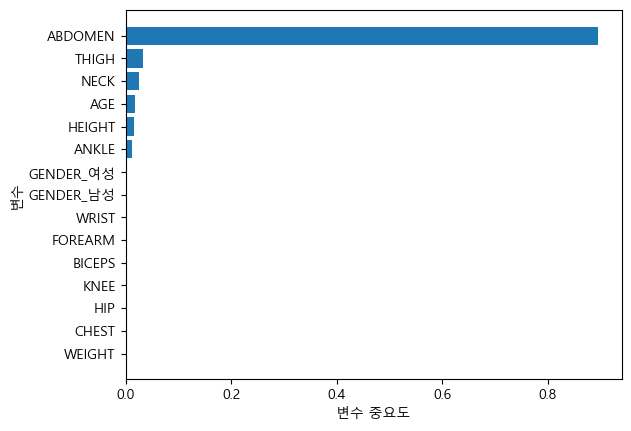

In [48]:
# 설명변수 중요도 그래프
# 중요도가 높은 변수를 상위에 그림
df_importance.sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance))
plt.barh(y = coordinates, width = df_importance["Importance"])
plt.yticks(coordinates, df_importance["Feature"])
plt.xlabel("변수 중요도")
plt.ylabel("변수")

In [51]:

from sklearn.model_selection import GridSearchCV

# GridSearchCV를 이용한 최적 parameter 찾기
estimator = DecisionTreeRegressor()
# 구하고자 하는 parameter와 범위
param_grid = {"criterion": ["mse", "friedman_mse", "mae"], "max_features": ["auto", "sqrt", "log2"],
              "max_depth": para_depth, "min_samples_split": para_split,
              "min_samples_leaf": para_leaf}
# 설명력이 높은 최적 parameter 찾기
grid_dt = GridSearchCV(estimator, param_grid, scoring="r2", n_jobs = -1)
grid_dt.fit(df_train_x, df_train_y)

print("best estimator model: \n{}".format(grid_dt.best_estimator_))
print("\nbest parameter: \n{}".format(grid_dt.best_params_))
print("\nbest score: \n{}".format(grid_dt.best_score_.round(3)))

best estimator model: 
DecisionTreeRegressor(criterion='friedman_mse', max_depth=4,
                      max_features='auto', min_samples_leaf=18,
                      min_samples_split=38)

best parameter: 
{'criterion': 'friedman_mse', 'max_depth': 4, 'max_features': 'auto', 'min_samples_leaf': 18, 'min_samples_split': 38}

best score: 
0.598
